# CNN: Convolutional Neural Network

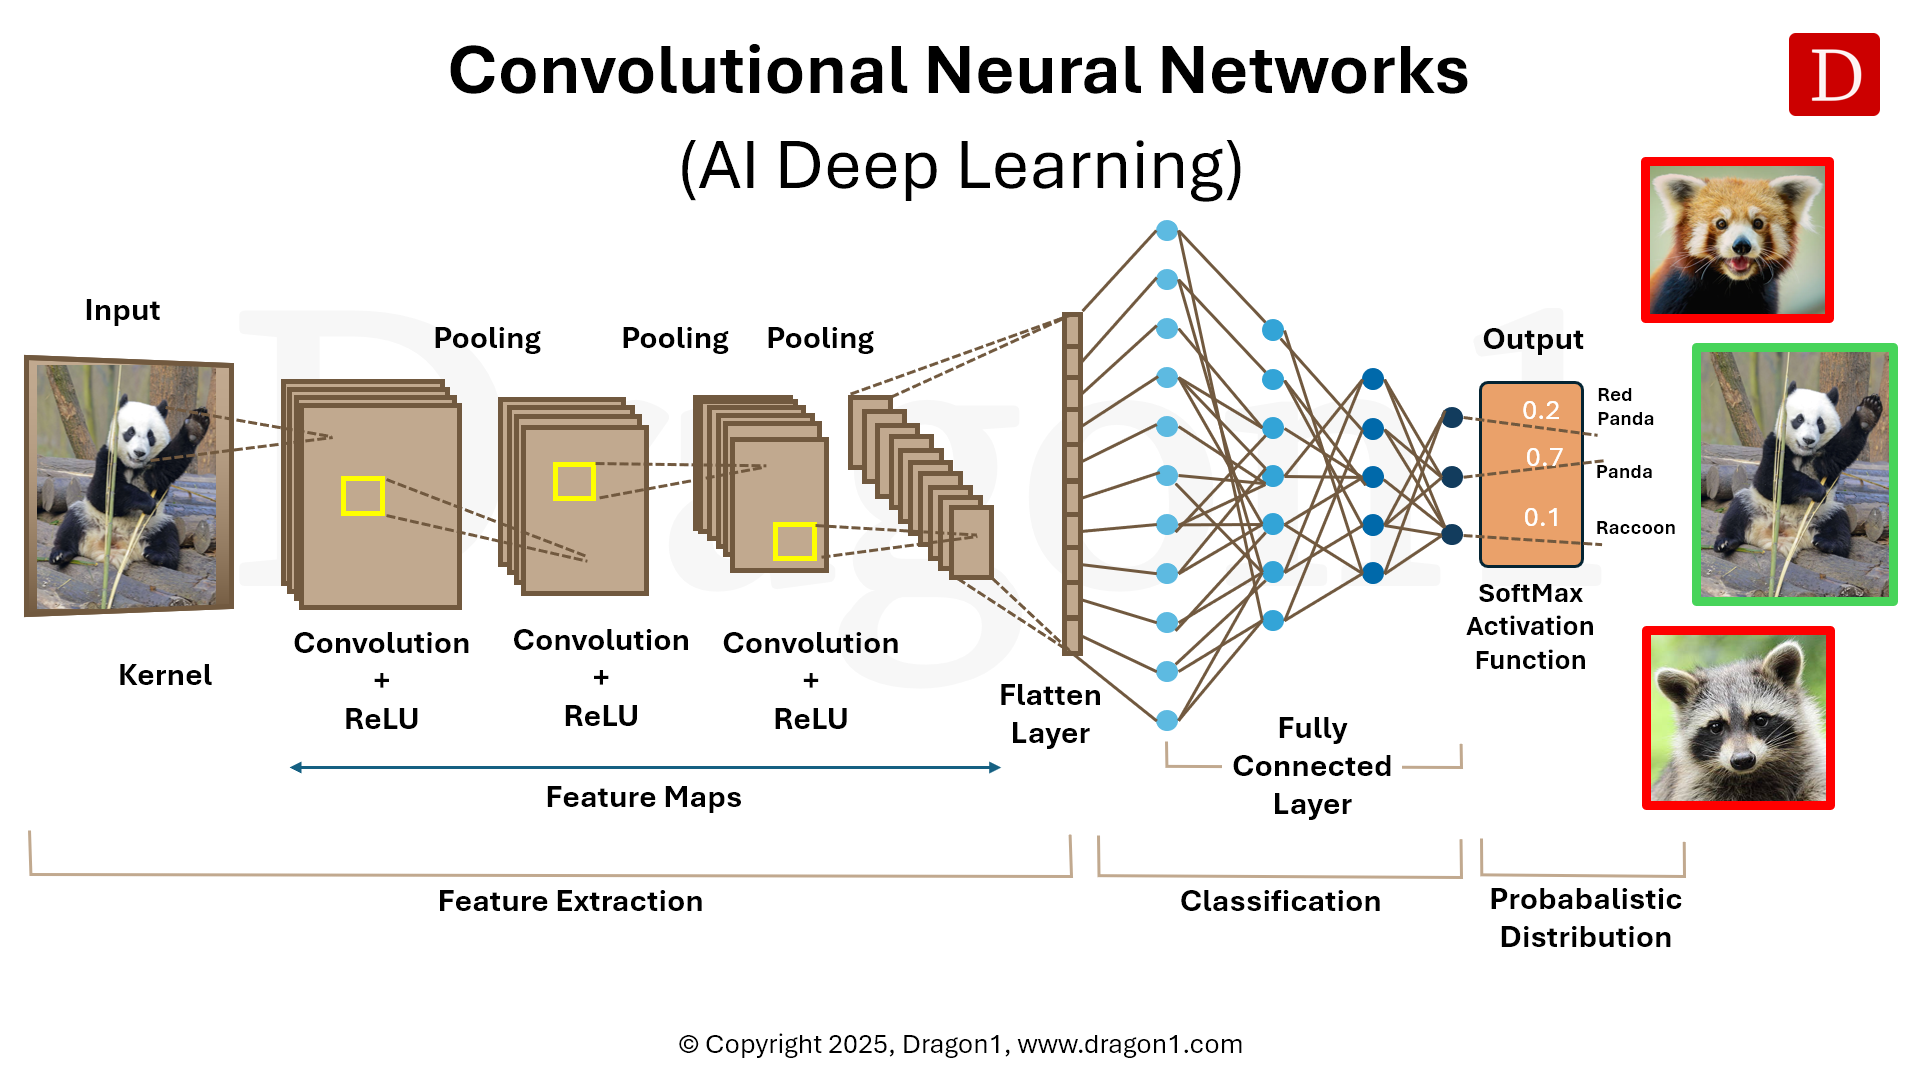

In [1]:
# Reg: Sales, Numerical: ANN
# Image dataset, Video : CNN

In [3]:
# Step 1 Import Required Modules

In [7]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import cv2
print('Done')

Done


In [8]:
# pip install opencv-python

In [11]:
(X_train,y_train),(X_test,y_test) = cifar10.load_data()
print('Done')

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 408s 2us/step
Done


In [12]:
# RNN: NLP: SLM: Small Language Models< Transformer Architecture, GPT: LLM: Large language Models
# Image-video: OPEN CV, CNN,

In [13]:
X_train.shape

(50000, 32, 32, 3)

In [14]:
X_test.shape

(10000, 32, 32, 3)

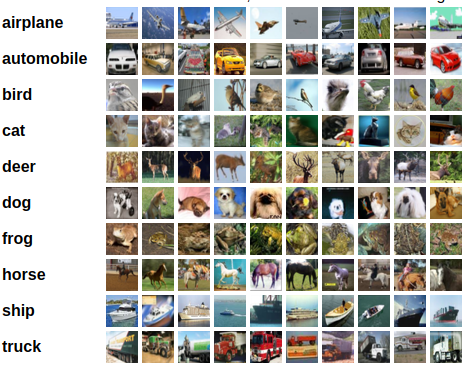

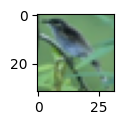

In [21]:
plt.figure(figsize = (1,1))
plt.imshow(X_train[800])
plt.show()

In [22]:
X_train[800].shape

(32, 32, 3)

In [23]:
X_train.min()

np.uint8(0)

In [24]:
X_train.max()

np.uint8(255)

In [25]:
# min_max, standard_scaler

In [26]:
X_train_sca = X_train/255
X_test_sca = X_test/255


In [27]:
X_train_sca.max()

np.float64(1.0)

In [28]:
X_train_sca.max()

np.float64(1.0)

In [29]:
classes = ['airplane','automobile','bird',
           'cat','deer','dog','frog','horse',
           'ship','truck']
print(classes)

['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [30]:
# H/w Create a of ANN to solve this Problem:

In [32]:
X_train_sca.shape[1:]

(32, 32, 3)

In [33]:
model_ann = Sequential([
    Flatten(),
    Dense(100,activation='relu', input_shape = X_train_sca.shape[1:]),
    Dense(1000,activation='relu'),
    Dense(len(classes),activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [36]:
model_ann.compile(optimizer = 'adam',loss = 'sparse_categorical_crossentropy',
                  metrics = ['accuracy'])

In [37]:
model_ann.fit(X_train_sca,y_train,epochs=6)

Epoch 1/6
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - accuracy: 0.0986 - loss: 11.3975
Epoch 2/6
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.0997 - loss: 12.5612
Epoch 3/6
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.1014 - loss: 13.5748
Epoch 4/6
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.0999 - loss: 13.6064
Epoch 5/6
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.0984 - loss: 13.6401
Epoch 6/6
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.0990 - loss: 13.5824


# Solve using CNN

In [38]:
from tensorflow.keras.layers import Conv2D, MaxPool2D
print('Done')

Done


In [43]:
model_cnn = Sequential([
    Conv2D(32,(3,3), padding='same', activation='relu'),
    MaxPool2D((2,2)),

    # Conv2D(64,(3,3), padding='same', activation='relu'),
    # MaxPool2D((2,2)),

    # Conv2D(64,(3,3), padding='same', activation='relu'),
    # MaxPool2D((2,2)),

    Conv2D(32,(3,3), padding='same', activation='relu'),
    MaxPool2D((2,2)),

    Flatten(),
    Dense(100,activation='relu'),
    # Dense(500,activation='relu'),
    Dense(len(classes),activation='softmax')


])

In [44]:
model_cnn.compile(optimizer = 'adam',loss = 'sparse_categorical_crossentropy',
                  metrics = ['accuracy'])

In [45]:
model_cnn.fit(X_train_sca,y_train,epochs=20)

Epoch 1/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 68s 42ms/step - accuracy: 0.4015 - loss: 1.6514
Epoch 2/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 67s 43ms/step - accuracy: 0.6126 - loss: 1.1049
Epoch 3/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 63s 40ms/step - accuracy: 0.6701 - loss: 0.9450
Epoch 4/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 40ms/step - accuracy: 0.6969 - loss: 0.8695
Epoch 5/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 63s 40ms/step - accuracy: 0.7228 - loss: 0.7963
Epoch 6/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 40ms/step - accuracy: 0.7466 - loss: 0.7237
Epoch 7/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 89s 45ms/step - accuracy: 0.7624 - loss: 0.6814
Epoch 8/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 79s 43ms/step - accuracy: 0.7814 - loss: 0.6259
Epoch 9/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 43ms/step - accuracy: 0.7993 - loss: 0.5730
Epoch 10/20
 995/1563 ━━━━━━━━━━━━━━━━━━━━ 23s 41ms/step - accuracy: 0.8127 - loss: 0.5345

KeyboardInterrupt: 

In [ ]:
y_pred_cnn = model_cnn.predict(X_test_sca)

In [ ]:
final_y_pred = [np.argmax(i) for i in y_pred_cnn]

In [ ]:
# Confusion_matrix, classification_report,
